# Credit Score Classification — EDA & Modelling
**DTSC6012001 – Model Deployment | Final Project**
Nama : Vinson Nicholas Sorensen

**Dataset C** — 25.000 baris dari 11.254 nasabah, 28 kolom, target: `Credit_Score` (Good / Standard / Poor)

---
## Outline
1. Data Loading & Profiling
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Preprocessing
4. Feature Engineering & Split
5. Modelling — Eksperimen 4 Model
6. Perbandingan Model & Evaluasi Akhir
7. Kesimpulan


## 1. Import Library & Load Data

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

df_raw = pd.read_csv('data_C.csv', index_col=0)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (25000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.05,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.00,Standard,2500.04,27.58,9 Years and 8 Months,Yes,26.17,92.51897591535379,High_spent_Small_value_payments,303.92,Standard
1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.57,9,10,1663,2,"Personal Loan, and Student Loan",58,14,15.53,6.00,Standard,2149.9,23.45,NaN,Yes,11.56,54.46174813453877,Low_spent_Medium_value_payments,309.13,Poor
2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.07,1,6,2,1,Auto Loan,25,4,5.04,1.00,Good,387.53,31.10,24 Years and 3 Months,No,98.03,478.3574716999517,High_spent_Small_value_payments,920.82,Standard


## 2. Exploratory Data Analysis

In [2]:
# 2.1 Tipe data & missing values
info_df = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'non_null': df_raw.count(),
    'missing': df_raw.isna().sum(),
    'missing_%': (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    'unique': df_raw.nunique()
})
info_df.sort_values('missing', ascending=False)

,dtype,non_null,missing,missing_%,unique
Monthly_Inhand_Salary,float64,21164,3836,15.34,10830
Type_of_Loan,str,22148,2852,11.41,5731
Name,str,22570,2430,9.72,8995
Credit_History_Age,str,22760,2240,8.96,403
Num_of_Delayed_Payment,str,23208,1792,7.17,235
Amount_invested_monthly,str,23866,1134,4.54,22773
Num_Credit_Inquiries,float64,24528,472,1.89,395
Monthly_Balance,float64,24699,301,1.20,24699
Month,str,25000,0,0.00,8
Age,str,25000,0,0.00,551


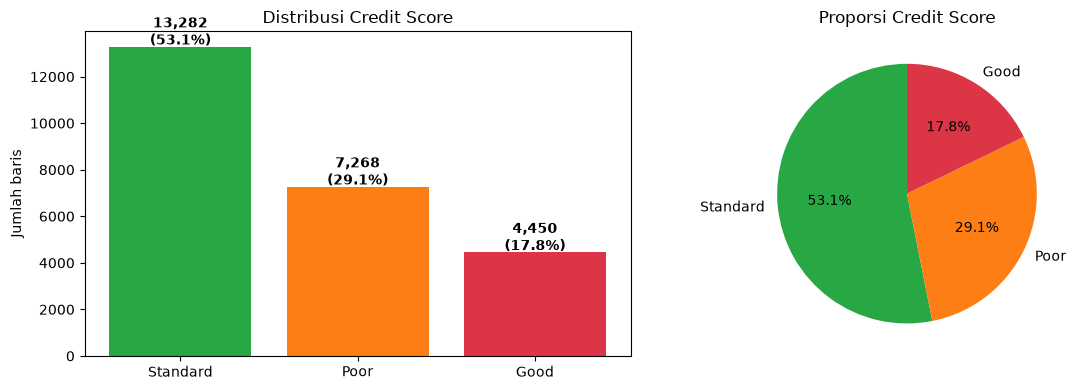


Kesimpulan: Dataset IMBALANCED → pakai F1 macro sebagai metrik utama, bukan accuracy


In [3]:
# 2.2 Distribusi target (imbalanced?)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_raw['Credit_Score'].value_counts()
colors = ['#28a745', '#fd7e14', '#dc3545']

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Distribusi Credit Score')
axes[0].set_ylabel('Jumlah baris')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 100, f'{val:,}\n({val/len(df_raw)*100:.1f}%)',
                 ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Credit Score')

plt.tight_layout()
plt.show()
print('\nKesimpulan: Dataset IMBALANCED → pakai F1 macro sebagai metrik utama, bukan accuracy')

In [4]:
# 2.3 Sample nilai kotor yang perlu dibersihkan
print('=== Contoh nilai kotor di dataset ===')
print()
print('Age (beberapa baris):')
print(df_raw['Age'].value_counts().tail(10).to_string())
print()
print('Occupation (nilai kotor):')
print(df_raw['Occupation'].value_counts().head(20).to_string())
print()
print('Credit_History_Age (format teks):')
print(df_raw['Credit_History_Age'].dropna().head(5).tolist())
print()
print('Amount_invested_monthly (format aneh):')
unusual = df_raw['Amount_invested_monthly'].astype(str).str.contains('_', na=False)
print(df_raw.loc[unusual, 'Amount_invested_monthly'].head(5).tolist())

=== Contoh nilai kotor di dataset ===

Age (beberapa baris):
Age
1066    1
3675    1
8204    1
4615    1
2764    1
4967    1
8200    1
1028    1
6579    1
4824    1

Occupation (nilai kotor):
Occupation
_______          1765
Lawyer           1642
Mechanic         1621
Teacher          1618
Developer        1580
Journalist       1568
Scientist        1558
Accountant       1553
Media_Manager    1552
Architect        1550
Engineer         1549
Entrepreneur     1511
Doctor           1504
Manager          1497
Musician         1491
Writer           1441

Credit_History_Age (format teks):
['9 Years and 8 Months', '24 Years and 3 Months', '17 Years and 7 Months', '14 Years and 7 Months', '2 Years and 4 Months']

Amount_invested_monthly (format aneh):
['__10000__', '__10000__', '__10000__', '__10000__', '__10000__']


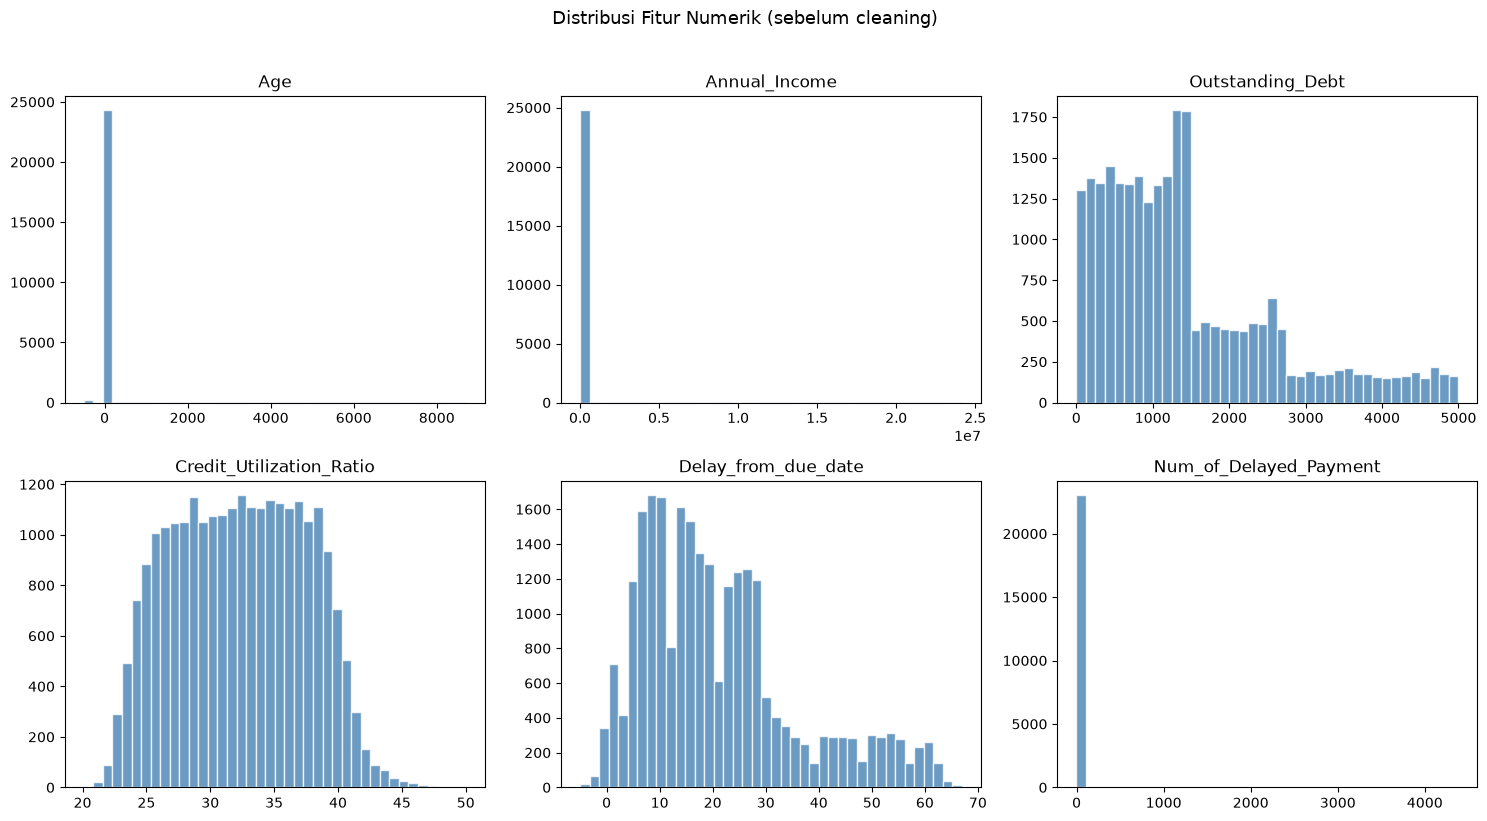

In [5]:
# 2.4 Distribusi fitur numerik utama
numeric_cols = ['Age', 'Annual_Income', 'Outstanding_Debt',
                'Credit_Utilization_Ratio', 'Delay_from_due_date',
                'Num_of_Delayed_Payment']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    data = pd.to_numeric(df_raw[col].astype(str).str.extract(r'(-?[\d.]+)', expand=False),
                         errors='coerce').dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}')
    ax.set_xlabel('')
plt.suptitle('Distribusi Fitur Numerik (sebelum cleaning)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Catatan:

Grafik di atas masih memakai data sebelum dibersihkan. Beberapa kolom, seperti `Age` dan `Num_of_Delayed_Payment`, punya ekor yang sangat panjang karena nilai salah input (umur sampai 8.697 tahun, keterlambatan bayar sampai 4.384 kali). Nilai seperti ini membuat sebagian besar data terjepit di batang paling kiri. Penanganannya ada di bagian 3.

### 2.5 Satu nasabah muncul di beberapa baris

Kolom `Customer_ID` menunjukkan bahwa satu nasabah bisa punya beberapa baris, satu untuk setiap bulan. Ini penting untuk cara membagi data.

In [6]:
per_nasabah = df_raw.groupby('Customer_ID').size()
print(f'Jumlah baris   : {len(df_raw):,}')
print(f'Jumlah nasabah : {per_nasabah.size:,}')
print('\nBaris per nasabah:')
print(per_nasabah.value_counts().sort_index().to_string())

multi = per_nasabah[per_nasabah > 1].index
label_sama = df_raw[df_raw['Customer_ID'].isin(multi)].groupby('Customer_ID')['Credit_Score'].nunique().eq(1)
print(f'\nNasabah dengan >1 baris yang Credit_Score-nya sama di semua bulan: {label_sama.mean():.1%}')

Jumlah baris   : 25,000
Jumlah nasabah : 11,254

Baris per nasabah:
1    3375
2    3919
3    2473
4    1132
5     298
6      49
7       8

Nasabah dengan >1 baris yang Credit_Score-nya sama di semua bulan: 67.8%


Dari 25.000 baris hanya ada 11.254 nasabah. Sebanyak 7.879 nasabah (70%) punya lebih dari satu baris, sampai 7 bulan. Pada nasabah yang punya lebih dari satu baris, 67,8% Credit_Score-nya sama di semua bulan, dan data seperti pekerjaan dan pendapatan hampir selalu sama.

Akibatnya, kalau data dibagi acak per baris, sekitar 80% baris di data test milik nasabah yang juga ada di data latih. Model lalu dinilai pada orang yang sudah pernah dilihatnya, sehingga skornya terlihat lebih tinggi dari kemampuan sebenarnya. Karena itu data dibagi per nasabah (`GroupShuffleSplit`), dan cross-validation juga dibagi per nasabah (`StratifiedGroupKFold`).

## 3. Data Cleaning & Preprocessing

### Masalah yang ditemukan di dataset:
| Masalah | Contoh | Solusi |
|---------|--------|--------|
| Placeholder kotor | `_______`, `#F%$D@*&8`, `NM` | Ganti dengan NaN |
| Numerik tersimpan sbg string | `20364.57_`, `3_` | Strip non-numerik, konversi float |
| Format teks spesial | `9 Years and 8 Months` | Parse ke total bulan |
| Nilai salah input | umur 4824, jumlah pinjaman -100, suku bunga 1663% | Ganti dengan NaN, lalu diisi imputer |
| Kolom identifier | ID, SSN, Name | Drop (tidak prediktif) |
| Satu nasabah di beberapa baris | 25.000 baris dari 11.254 nasabah | Split train/test dan CV per nasabah |

Nilai salah input sengaja tidak dipotong ke batas (misalnya umur 4824 dijadikan 90). Kalau dipotong, muncul ratusan nasabah "berumur 90 tahun" yang sebenarnya tidak ada, dan model belajar dari nilai palsu itu. Lebih jujur menganggapnya tidak diketahui (NaN) lalu mengisinya dengan median.

Batas wajar tiap kolom diambil dari data: nilai asli berkumpul di satu rentang, lalu ada celah kosong sebelum nilai rusak. Contohnya suku bunga asli 1–34%, tidak ada nilai 35–72%, dan nilai rusak mulai dari 73%.

In [7]:
DROP_COLS     = ['ID','Customer_ID','SSN','Name','Month','Type_of_Loan']
DIRTY_VALUES  = ['_______','#F%$D@*&8','!@9#%8','__10000__','NM','_','']
STR_TO_FLOAT  = ['Age','Annual_Income','Num_of_Loan','Num_of_Delayed_Payment',
                 'Changed_Credit_Limit','Outstanding_Debt','Amount_invested_monthly']
NUMERIC_COLS  = ['Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts',
                 'Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
                 'Num_of_Delayed_Payment','Changed_Credit_Limit','Num_Credit_Inquiries',
                 'Outstanding_Debt','Credit_Utilization_Ratio','Total_EMI_per_month',
                 'Amount_invested_monthly','Monthly_Balance']
# Rentang wajar (sama dengan VALID_RANGES di preprocessing.py). Di luar rentang → NaN.
VALID_RANGES  = {'Age':(14,100), 'Annual_Income':(0,250_000), 'Num_Bank_Accounts':(0,15),
                 'Num_Credit_Card':(0,15), 'Interest_Rate':(0,50), 'Num_of_Loan':(0,15),
                 'Num_Credit_Inquiries':(0,25), 'Num_of_Delayed_Payment':(0,30),
                 'Total_EMI_per_month':(0,5_000)}

def parse_credit_history(val):
    """Konversi '9 Years and 8 Months' → 116 bulan"""
    if pd.isna(val): return np.nan
    m = re.match(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(val), re.I)
    return int(m.group(1))*12 + int(m.group(2)) if m else np.nan

def str_to_float(val):
    """Strip karakter aneh → float. Contoh: '20364.57_' → 20364.57"""
    if pd.isna(val): return np.nan
    s = re.sub(r'[^\d.\-]', '', str(val).strip())
    try: return float(s)
    except: return np.nan

jumlah_salah_input = {}

def clean_data(df):
    df = df.copy()
    df.replace(DIRTY_VALUES, np.nan, inplace=True)                           # 1. Placeholder → NaN
    df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(parse_credit_history)
    df.drop(columns=['Credit_History_Age'], errors='ignore', inplace=True)   # 2. Parse teks
    for col in STR_TO_FLOAT:                                                  # 3. String → float
        if col in df.columns: df[col] = df[col].apply(str_to_float)
    for col in NUMERIC_COLS:
        if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
    for col, (lo, hi) in VALID_RANGES.items():                               # 4. Salah input → NaN
        salah = (df[col] < lo) | (df[col] > hi)
        jumlah_salah_input[col] = int(salah.sum())
        df.loc[salah, col] = np.nan
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True) # 5. Drop ID cols
    return df

df_clean = clean_data(df_raw.drop(columns=['Credit_Score']))
print('Shape sebelum cleaning:', df_raw.shape)
print('Shape setelah  cleaning:', df_clean.shape)
print('Missing values setelah cleaning:', df_clean.isna().sum().sum())
print('\nNilai salah input yang diganti NaN:')
print(pd.Series(jumlah_salah_input).to_string())

Shape sebelum cleaning: (25000, 28)
Shape setelah  cleaning: (25000, 21)
Missing values setelah cleaning: 27955

Nilai salah input yang diganti NaN:
Age                        701
Annual_Income              224
Num_Bank_Accounts          362
Num_Credit_Card            568
Interest_Rate              534
Num_of_Loan               1108
Num_Credit_Inquiries       417
Num_of_Delayed_Payment     326
Total_EMI_per_month        784


## 4. Feature Engineering & Split

In [8]:
NUMERIC_FEATURES = [
    'Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts',
    'Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
    'Num_of_Delayed_Payment','Changed_Credit_Limit','Num_Credit_Inquiries',
    'Outstanding_Debt','Credit_Utilization_Ratio','Credit_History_Age_Months',
    'Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance'
]
CATEGORICAL_FEATURES = ['Occupation','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']
TARGET_MAP = {'Good':0,'Standard':1,'Poor':2}

y = df_raw['Credit_Score'].map(TARGET_MAP)
X = df_clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
groups = df_raw['Customer_ID']

# Split per nasabah: semua baris satu nasabah masuk ke train saja atau test saja
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train    = groups.iloc[train_idx]

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Nasabah yang ada di train DAN test: {len(set(groups_train) & set(groups.iloc[test_idx]))}')
pd.DataFrame({'train': y_train.value_counts(normalize=True),
              'test':  y_test.value_counts(normalize=True)}).rename(index={0:'Good',1:'Standard',2:'Poor'})

X_train: (19989, 21) | X_test: (5011, 21)
Nasabah yang ada di train DAN test: 0


,train,test
Credit_Score,,
Standard,0.53,0.53
Poor,0.29,0.29
Good,0.18,0.18


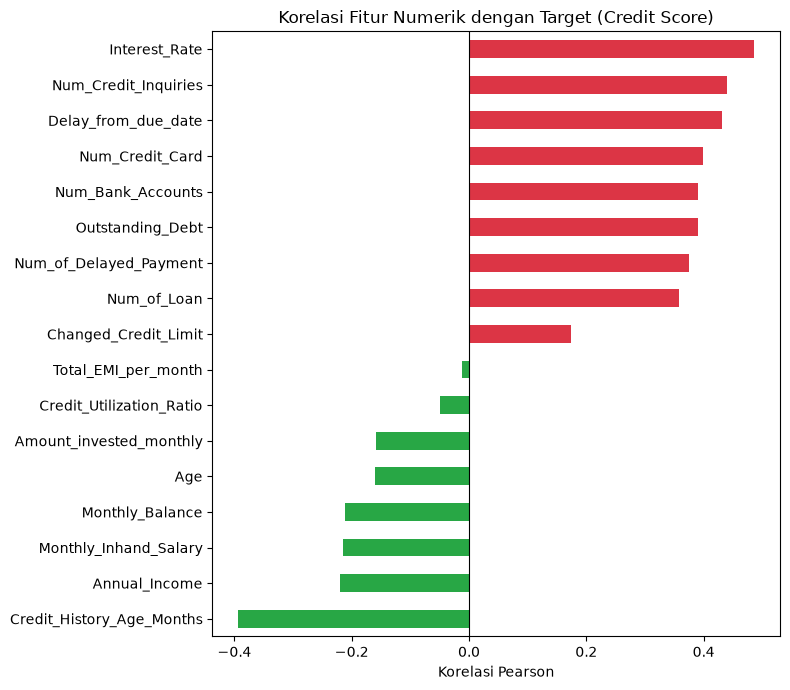

In [9]:
# Korelasi fitur numerik dengan target
corr_df = X_train[NUMERIC_FEATURES].copy()
corr_df['target'] = y_train.values
corr = corr_df.corr()['target'].drop('target').sort_values()

plt.figure(figsize=(8, 7))
corr.plot(kind='barh', color=['#dc3545' if v > 0 else '#28a745' for v in corr.values])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur Numerik dengan Target (Credit Score)')
plt.xlabel('Korelasi Pearson')
plt.tight_layout()
plt.show()

Cara membaca: target diberi angka Good = 0, Standard = 1, Poor = 2. Korelasi positif (merah) berarti semakin besar nilai fitur, semakin condong ke Poor. Korelasi negatif (hijau) berarti semakin condong ke Good.

- Paling berkaitan dengan skor buruk: suku bunga (0,49), jumlah permintaan kredit (0,44), keterlambatan dari jatuh tempo (0,43), serta jumlah kartu kredit dan rekening bank (sekitar 0,40).
- Paling berkaitan dengan skor baik: lama riwayat kredit (-0,39), lalu pendapatan dan saldo bulanan (sekitar -0,2).
- Rasio pemakaian kredit dan cicilan bulanan hampir tidak berkaitan (mendekati 0).

Korelasi hanya menangkap hubungan lurus. Karena Standard berada di tengah, angka ini cukup masuk akal untuk dibaca, tetapi bukan ukuran pasti pengaruh fitur di model.

In [10]:
# Fitur kategorikal: porsi kelas untuk setiap nilai (data latih)
label_nama = y_train.map({0: 'Good', 1: 'Standard', 2: 'Poor'})
for kolom in ['Credit_Mix', 'Payment_of_Min_Amount']:
    display((pd.crosstab(X_train[kolom], label_nama, normalize='index')[['Good', 'Standard', 'Poor']] * 100).round(0).astype(int))

Credit_Score,Good,Standard,Poor
Credit_Mix,,,
Bad,2,38,60
Good,49,36,15
Standard,5,73,22


Credit_Score,Good,Standard,Poor
Payment_of_Min_Amount,,,
No,38,49,13
Yes,4,56,40


Dua fitur kategorikal ini sangat membedakan kelas. Nasabah dengan `Credit_Mix` Bad 60% berada di kelas Poor dan hanya 2% di Good, sedangkan Credit_Mix Good hampir separuhnya berada di kelas Good. Nasabah yang hanya membayar tagihan minimum (`Payment_of_Min_Amount` = Yes) 40% berada di kelas Poor, dibanding 13% untuk yang tidak.

## 5. Modelling — Eksperimen 4 Model

### Alasan pemilihan model:
- Baseline — selalu menebak kelas terbanyak (Standard). Model lain harus jelas lebih baik dari ini.
- **Logistic Regression** — baseline linear, cepat, interpretable
- **Decision Tree** — non-linear, mudah dijelaskan, rentan overfit
- **Random Forest** — ensemble of trees, robust, umumnya unggul
- **Gradient Boosting** — boosting, sering jadi model terbaik untuk tabular data

### Strategi:
- Setiap model dibungkus dalam sklearn **Unified Pipeline** (ColumnTransformer + Classifier)
- Pakai `class_weight='balanced'` untuk menangani imbalanced dataset (kecuali Gradient Boosting, yang tidak punya pengaturan ini)
- Fitur kategorikal di-encode dengan one-hot, karena Occupation dan Payment_Behaviour tidak punya urutan
- Metrik utama: **F1 macro** (memberi bobot sama pada tiap kelas)
- Model dibandingkan dan dipilih dengan cross-validation per nasabah di data latih (`StratifiedGroupKFold`). Data test baru dipakai sekali di akhir, untuk model yang sudah terpilih. Kalau model dipilih berdasarkan skor test, skor test itu ikut "terpakai" untuk memilih dan tidak lagi netral.

In [11]:
# Build ColumnTransformer (reusable untuk semua model)
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # isi missing dengan median
    ('scaler',  StandardScaler())                    # normalisasi numerik
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # isi missing dengan modus
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # kategori tanpa urutan → one-hot
])
col_transformer = ColumnTransformer([
    ('num', numeric_pipe,      NUMERIC_FEATURES),
    ('cat', categorical_pipe,  CATEGORICAL_FEATURES)
], remainder='drop')

# Definisi model yang akan dieksperimen
MODELS = [
    ('Baseline (selalu Standard)',
     DummyClassifier(strategy='most_frequent')),
    ('LogisticRegression',
     LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    ('DecisionTree',
     DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced')),
    ('RandomForest',
     RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42,
                            n_jobs=2, class_weight='balanced')),
    ('GradientBoosting',
     GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)),
]

# CV per nasabah di data latih. Data test belum disentuh sama sekali di tahap ini.
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

results = []
for name, clf in MODELS:
    print(f'Cross-validation {name}...')
    pipe = Pipeline([('prep', clone(col_transformer)), ('clf', clf)])
    skor = cross_validate(pipe, X_train, y_train, groups=groups_train, cv=cv, n_jobs=1,
                          scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])
    results.append({
        'Model': name,
        'Accuracy':  skor['test_accuracy'].mean(),
        'Precision': skor['test_precision_macro'].mean(),
        'Recall':    skor['test_recall_macro'].mean(),
        'F1 Macro':  skor['test_f1_macro'].mean(),
        'F1 Std':    skor['test_f1_macro'].std(),
    })
    print(f"  CV F1 macro = {results[-1]['F1 Macro']:.4f} ± {results[-1]['F1 Std']:.4f}")

results_df = pd.DataFrame(results).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
print()
results_df

Cross-validation Baseline (selalu Standard)...


  CV F1 macro = 0.2315 ± 0.0000
Cross-validation LogisticRegression...


  CV F1 macro = 0.6385 ± 0.0075
Cross-validation DecisionTree...


  CV F1 macro = 0.6421 ± 0.0115
Cross-validation RandomForest...


  CV F1 macro = 0.6650 ± 0.0087
Cross-validation GradientBoosting...


  CV F1 macro = 0.6530 ± 0.0027



,Model,Accuracy,Precision,Recall,F1 Macro,F1 Std
0,RandomForest,0.67,0.66,0.72,0.67,0.01
1,GradientBoosting,0.68,0.66,0.65,0.65,0.00
2,DecisionTree,0.65,0.63,0.67,0.64,0.01
3,LogisticRegression,0.65,0.63,0.68,0.64,0.01
4,Baseline (selalu Standard),0.53,0.18,0.33,0.23,0.00


In [12]:
from IPython.display import display

# Random Forest punya CV F1 macro tertinggi di perbandingan di atas, jadi model ini yang di-tuning.
print("Memulai Hyperparameter Tuning untuk Random Forest...")

# 1. Siapkan Pipeline khusus Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', clone(col_transformer)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=2))
])

# 2. Parameter Grid (sama dengan grid RandomForest di train.py)
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [8, 12, 16],
}

# 3. GridSearchCV dengan CV per nasabah (3 fold) dan n_jobs=1 (aman untuk memori)
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,                # StratifiedGroupKFold yang sama dengan perbandingan model
    scoring='f1_macro',
    n_jobs=1,
    verbose=1
)

# Menjalankan pencarian (groups wajib diisi supaya fold dibagi per nasabah)
grid_search.fit(X_train, y_train, groups=groups_train)

# 4. Tampilkan hasil
print(f"\n✅ Parameter Terbaik: {grid_search.best_params_}")
print(f"✅ Skor F1 Macro Terbaik (CV): {grid_search.best_score_:.4f}")

# 5. Visualisasi hasil eksperimen ke dalam tabel
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df = cv_results_df[['param_classifier__n_estimators', 'param_classifier__max_depth',
                               'mean_test_score', 'std_test_score', 'rank_test_score']]

print("\n--- Tabel Detail Eksperimen ---")
display(cv_results_df.sort_values(by='rank_test_score'))

Memulai Hyperparameter Tuning untuk Random Forest...


Fitting 3 folds for each of 9 candidates, totalling 27 fits



✅ Parameter Terbaik: {'classifier__max_depth': 16, 'classifier__n_estimators': 200}
✅ Skor F1 Macro Terbaik (CV): 0.6691

--- Tabel Detail Eksperimen ---


,param_classifier__n_estimators,param_classifier__max_depth,mean_test_score,std_test_score,rank_test_score
8,200,16,0.67,0.01,1
7,100,16,0.67,0.01,2
6,50,16,0.67,0.01,3
4,100,12,0.67,0.01,4
3,50,12,0.66,0.01,5
5,200,12,0.66,0.01,6
0,50,8,0.66,0.01,7
2,200,8,0.66,0.01,8
1,100,8,0.66,0.01,9


## 6. Perbandingan Model (CV) & Evaluasi Akhir di Data Test

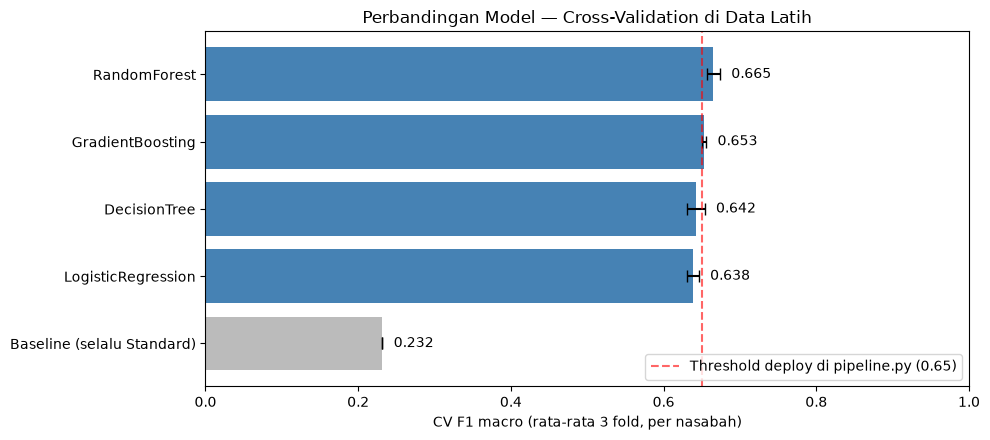

In [13]:
# Perbandingan semua model berdasarkan CV F1 macro di data latih
urut = results_df.sort_values('F1 Macro')
warna = ['#bbbbbb' if m.startswith('Baseline') else 'steelblue' for m in urut['Model']]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(urut['Model'], urut['F1 Macro'], xerr=urut['F1 Std'], color=warna, capsize=4)
for i, (v, s) in enumerate(zip(urut['F1 Macro'], urut['F1 Std'])):
    ax.text(v + s + 0.015, i, f'{v:.3f}', va='center')
ax.axvline(0.65, color='red', linestyle='--', alpha=0.6, label='Threshold deploy di pipeline.py (0.65)')
ax.set_xlim(0, 1.0)
ax.set_xlabel('CV F1 macro (rata-rata 3 fold, per nasabah)')
ax.set_title('Perbandingan Model — Cross-Validation di Data Latih')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

=== Best Model: RandomForest {'classifier__max_depth': 16, 'classifier__n_estimators': 200} ===
Test Accuracy  : 0.6929
Test Precision : 0.6792  (macro)
Test Recall    : 0.7371  (macro)
Test F1 macro  : 0.6886  (macro ← metrik utama)

              precision    recall  f1-score   support

        Good       0.54      0.84      0.66       909
    Standard       0.84      0.60      0.70      2645
        Poor       0.65      0.77      0.71      1457

    accuracy                           0.69      5011
   macro avg       0.68      0.74      0.69      5011
weighted avg       0.73      0.69      0.69      5011



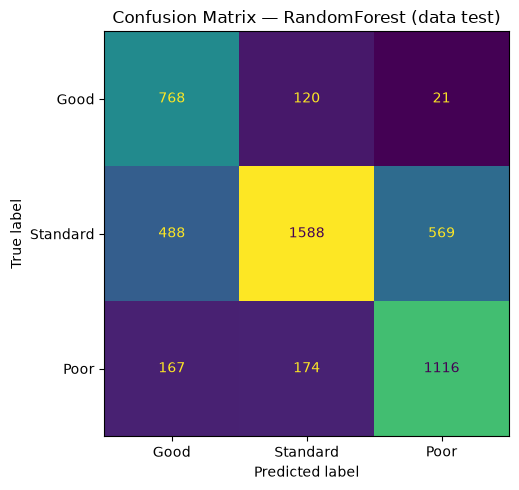

In [14]:
# Evaluasi akhir: model terpilih (hasil tuning, sudah di-refit ke seluruh data latih)
# dinilai SEKALI di data test, yang berisi nasabah yang tidak pernah dilihat saat training.
best_model_name = 'RandomForest'
best_pipe = grid_search.best_estimator_
y_pred_best = best_pipe.predict(X_test)

print(f'=== Best Model: {best_model_name} {grid_search.best_params_} ===')
print(f'Test Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Test Precision : {precision_score(y_test, y_pred_best, average="macro"):.4f}  (macro)')
print(f'Test Recall    : {recall_score(y_test, y_pred_best, average="macro"):.4f}  (macro)')
print(f'Test F1 macro  : {f1_score(y_test, y_pred_best, average="macro"):.4f}  (macro ← metrik utama)')
print()
print(classification_report(y_test, y_pred_best, target_names=['Good','Standard','Poor']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Good', 'Standard', 'Poor'],
    colorbar=False, ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name} (data test)')
plt.tight_layout()
plt.show()

### 6a. Seberapa besar pengaruh pembagian per nasabah?

Model hasil tuning dinilai ulang dengan cross-validation acak per baris, lalu dibandingkan dengan cross-validation per nasabah. Model, pembersihan data, dan data latihnya sama persis. Yang berbeda hanya cara membagi fold.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

model_terpilih = clone(grid_search.best_estimator_)
perbandingan_split = {}
for nama, pembagi in [('acak per baris', StratifiedKFold(n_splits=3, shuffle=True, random_state=42)),
                      ('per nasabah', cv)]:
    skor = cross_val_score(model_terpilih, X_train, y_train, groups=groups_train, cv=pembagi,
                           scoring='f1_macro', n_jobs=1)
    perbandingan_split[nama] = skor.mean()
pd.Series(perbandingan_split, name='CV F1 macro').map('{:.3f}'.format)

acak per baris    0.686
per nasabah       0.669
Name: CV F1 macro, dtype: str

Dengan pembagian acak, sebagian baris validasi milik nasabah yang juga ada di fold latih, sehingga skornya sedikit lebih tinggi. Selisihnya kecil (sekitar 0,02), jadi model tidak sekadar menghafal nasabah. Namun skor per nasabah tetap yang dipakai, karena lebih sesuai dengan cara model dipakai: menilai nasabah baru.

## 7. Kesimpulan

### Fitur yang Digunakan (21 fitur)
- 17 fitur numerik: Age, Annual_Income, Monthly_Inhand_Salary, Num_Bank_Accounts, Num_Credit_Card, Interest_Rate, Num_of_Loan, Delay_from_due_date, Num_of_Delayed_Payment, Changed_Credit_Limit, Num_Credit_Inquiries, Outstanding_Debt, Credit_Utilization_Ratio, Credit_History_Age_Months (hasil parsing), Total_EMI_per_month, Amount_invested_monthly, Monthly_Balance
- 4 fitur kategorikal: Occupation, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour

### Preprocessing yang Dilakukan
1. Placeholder kotor → NaN (`_______`, `#F%$D@*&8`, dll)
2. Numerik yang tersimpan sebagai string → float (strip karakter non-numerik)
3. Credit_History_Age → parsing teks ke total bulan
4. Nilai salah input di luar rentang wajar → NaN (5.024 nilai, misalnya 1.108 jumlah pinjaman yang mustahil, termasuk 977 nilai negatif, dan 701 umur yang mustahil)
5. Missing values → SimpleImputer (median untuk numerik, modus untuk kategorikal)
6. Encoding → OneHotEncoder untuk fitur kategorikal
7. Scaling → StandardScaler untuk fitur numerik
8. Split train/test 80:20 per nasabah, tidak ada nasabah yang muncul di keduanya

### Hasil Cross-Validation per Nasabah (data latih)
| Model | CV F1 macro |
|-------|-------------|
| Baseline (selalu Standard) | 0,232 |
| Logistic Regression | 0,638 |
| Decision Tree | 0,642 |
| Gradient Boosting | 0,653 |
| Random Forest | 0,665 |
| Random Forest setelah tuning (max_depth 16, 200 pohon) | 0,669 |

Semua model jauh di atas baseline. Random Forest terbaik, tetapi selisih antarmodel kecil (sekitar 0,01–0,03).

### Evaluasi Akhir di Data Test
Model terpilih dinilai sekali di data test (5.011 baris dari nasabah yang tidak pernah dilihat saat training):
- F1 macro 0,689, accuracy 0,693
- Recall Good 0,84 tetapi precision Good hanya 0,54: model cukup sering menebak nasabah Standard sebagai Good.
- Recall Standard 0,60 adalah yang terendah, karena Standard berada di tengah dan sering tertukar ke dua arah.

Skor test (0,689) sedikit lebih tinggi dari skor CV (0,669). Ini variasi biasa antar-pembagian data, jadi perkiraan yang lebih aman untuk kemampuan model adalah sekitar 0,67.

### Perbandingan dengan Versi Sebelumnya
Versi awal notebook ini membagi data acak per baris dan memilih model berdasarkan skor test. Bagian 6a mengukur pengaruh cara membagi data: dengan model dan pembersihan yang sama, cross-validation acak per baris memberi F1 macro 0,686, sedangkan per nasabah 0,669. Selisihnya kecil, jadi model memang belajar pola yang berguna, tetapi angka dari pembagian acak sedikit terlalu optimis.

### Keterbatasan
- Random Forest dengan max_depth 16 punya F1 latih 0,84 dibanding CV 0,67, jadi model masih overfit. Grid dengan min_samples_leaf atau max_depth yang lebih kecil bisa dicoba.
- Model untuk deployment dilatih dan disimpan oleh `pipeline.py` (folder Soal1bc), dengan cleaning, split, dan grid yang sama dengan notebook ini.